Edge cuts total: 3
Edge cuts: Any[(2, 3), (3, 7), (4, 7)]
Partitions: [[3, 4, 5, 6], [1, 2, 7, 8]]


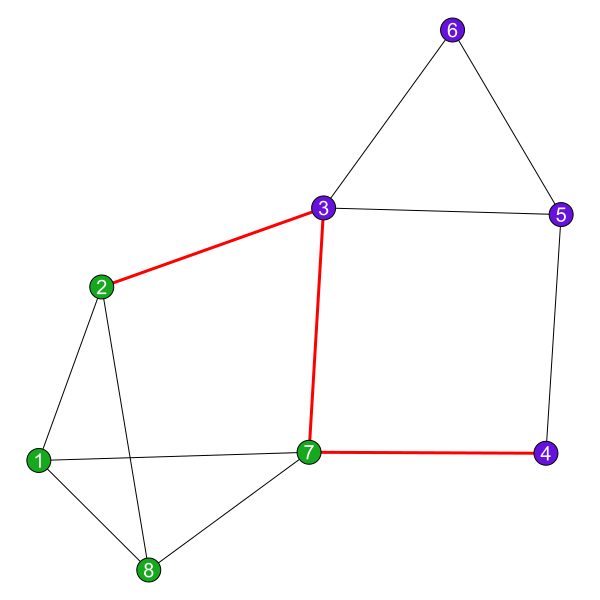

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 5 – Graph problems
#  Section: 5.5.1 – Graph Partitioning Problem (GPP)
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP    # Modeling language
using HiGHS   # Solver
using Graphs  # Graphs package
using Karnak  # Graphs Visualization package
using Colors  # Colors package
using Random  # Random number generation

# Function to plot the solution
function plot_solution(graph, x, y, k)
    n = Graphs.nv(graph)
    m = Graphs.ne(graph)

    # Use distinguishable_colors for better color selection
    colors = [Colors.RGB(rand(), rand(), rand()) for _ in 1:k]
    vertexfillcolors = fill(RGB(0,0,0), n)

    # Assign colors to vertices based on their partition
    partition = [findall(JuMP.value.(x[:,id]) .> 0.5) for id in 1:k]
    for id in 1:k
        vertexfillcolors[partition[id]] .= colors[id]
    end

    # Prepare edge colors and weights
    edgestrokecolors = fill(Colors.RGB(0,0,0), m)
    edgestrokeweights = fill(1, m)
    cut_edges = []
    for (e_id, e) in enumerate(Graphs.edges(graph))
        if JuMP.value(y[e_id]) > 0.5
            edgestrokecolors[e_id] = Colors.RGB(1, 0, 0)
            edgestrokeweights[e_id] = 3
            push!(cut_edges, (Graphs.src(e), Graphs.dst(e)))
        end
    end

    # Print results
    println("Edge cuts: ", cut_edges)
    println("Partition: ", partition)

    # Draw graph
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        drawgraph(
            graph,
            layout = stress,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = vertexfillcolors,
            edgestrokecolors = edgestrokecolors,
            edgestrokeweights = edgestrokeweights
        )
    end
end

# Function to solve the Graph Partitioning Problem (GPP)
function solve_gpp(graph; k = 2)
    # Total of vertices
    n = Graphs.nv(graph)

    # Total of edges
    m = Graphs.ne(graph)

    # Define lower and upper size limits for each partition
    L = floor(Int, n / k)
    U = ceil(Int, n / k)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:k], Bin)  # x[u,i] = 1 if vertex u is in partition i
    @variable(model, y[1:m], Bin)       # y[e] = 1 if edge e is a cut edge
    
    # Objective: minimize number of cut edges
    @objective(model, Min, sum(y))
        
    # Each vertex must be assigned to exactly one partition
    @constraint(model, [u in 1:n], sum(x[u, p] for p in 1:k) == 1)

    # Partition balance constraint
    @constraint(model, [p in 1:k], sum(x[u, p] for u in 1:n) >= L)
    @constraint(model, [p in 1:k], sum(x[u, p] for u in 1:n) <= U)

    # Define y[e] = 1 if edge connects different partitions
    for (e_id, e) in enumerate(Graphs.edges(graph))
        u, v = Graphs.src(e), Graphs.dst(e)
        for p in 1:k
            @constraint(model, y[e_id] >= x[u, p] - x[v, p])
            @constraint(model, y[e_id] >= x[v, p] - x[u, p])
        end
    end

    # Run the solver
    JuMP.optimize!(model)

    # Print solution
    println("Edge cuts total: ", Int(JuMP.objective_value(model)))
    
    # Plot solution
    plot_solution(graph, x, y, k)
end

# Set seed
Random.seed!(0)

# Create graph
graph = Graphs.Graph(8)

# Edges
edges = [(1,2), (1,7), (1,8), (2,3), 
         (2,8), (3,5), (3,6), (3,7), 
         (4,5), (4,7), (5,6), (7,8)]

# Add edges
for (u, v) in edges
    Graphs.add_edge!(graph, u, v)
end

# Solve the Graph Partitioning Problem
solve_gpp(graph, k = 2)